In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Files extracted:")
for file in os.listdir('/content/dataset'):
    print(file)

Saving real+estate+valuation+data+set.zip to real+estate+valuation+data+set.zip
Files extracted:
Real estate valuation data set.xlsx


In [4]:
data_file = '/content/dataset/Real estate valuation data set.xlsx'

data = pd.read_excel(data_file)

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (414, 8)


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
print("Dataset Information")
print("=" * 50)

print("Shape:", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Information
Shape: (414, 8)

Column Names:
['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']

Missing Values:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


In [6]:
X = data.iloc[:, :-1]

print("Features used for PCA:")
print(X.columns.tolist())

print("\nShape of feature data:", X.shape)

Features used for PCA:
['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']

Shape of feature data: (414, 7)


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardized Data:")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

Standardized Data:


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,-1.727872,-0.824722,1.255628,-0.792495,2.007407,1.125430,0.448762
1,-1.719505,-0.824722,0.157086,-0.616612,1.667503,0.912444,0.401139
2,-1.711137,1.542244,-0.387791,-0.414015,0.307885,1.486860,0.688183
3,-1.702770,1.246373,-0.387791,-0.414015,0.307885,1.486860,0.688183
4,-1.694402,-1.120593,-1.117223,-0.549997,0.307885,0.834188,0.592937


In [8]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

pca_2_df = pd.DataFrame(
    X_pca_2,
    columns=['PC1', 'PC2']
)

print("PCA Transformed Data:")
display(pca_2_df.head())

PCA Transformed Data:


,PC1,PC2
0,-2.142775,1.398270
1,-1.760646,0.754387
2,-1.369964,1.781239
3,-1.376153,1.602551
4,-1.158473,-0.276675


In [9]:
print("Explained Variance Ratio:")
print(pca_2.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca_2.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.38206108 0.15524908]

Total Explained Variance:
0.5373101607877153


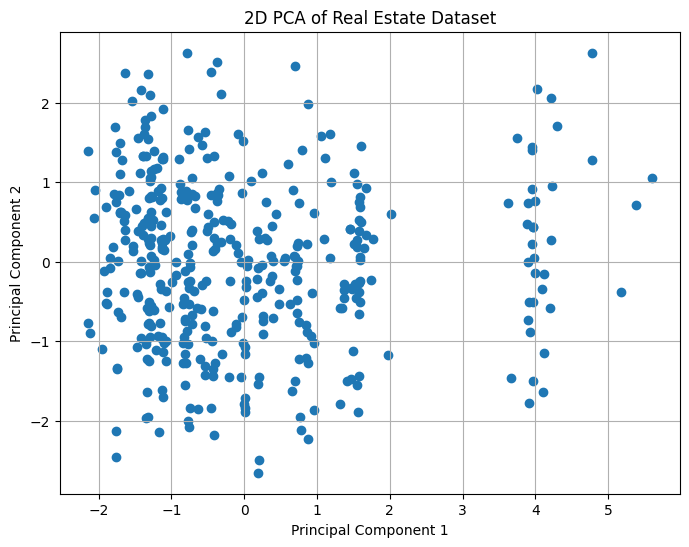

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1]
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA of Real Estate Dataset')

plt.grid(True)
plt.show()

In [11]:
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3)

X_pca_3 = pca_3.fit_transform(X_scaled)

pca_3_df = pd.DataFrame(
    X_pca_3,
    columns=['PC1', 'PC2', 'PC3']
)

print("3D PCA Data:")
display(pca_3_df.head())

print("\nExplained Variance Ratio:")
print(pca_3.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca_3.explained_variance_ratio_.sum())

3D PCA Data:


,PC1,PC2,PC3
0,-2.142775,1.398270,0.960746
1,-1.760646,0.754387,0.054668
2,-1.369964,1.781239,-1.587290
3,-1.376153,1.602551,-1.442557
4,-1.158473,-0.276675,-0.916486



Explained Variance Ratio:
[0.38206108 0.15524908 0.14121961]

Total Explained Variance:
0.6785297659376772


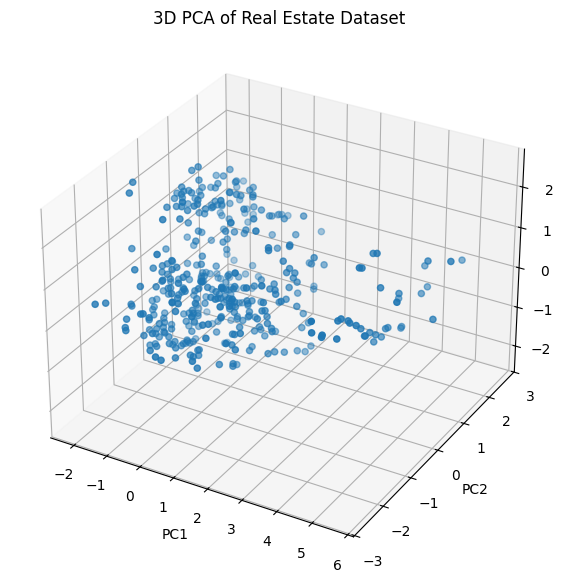

In [12]:
fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3[:, 0],
    X_pca_3[:, 1],
    X_pca_3[:, 2]
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.set_title('3D PCA of Real Estate Dataset')

plt.show()

In [13]:
loadings = pd.DataFrame(
    pca_3.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)

print("PCA Loadings:")
display(loadings)

PCA Loadings:


,PC1,PC2,PC3
No,0.004429,-0.562878,0.318047
X1 transaction date,0.021043,0.588021,-0.480183
X2 house age,-0.004625,0.544358,0.809945
X3 distance to the nearest MRT station,0.570516,0.073775,0.020843
X4 number of convenience stores,-0.461145,0.091652,0.052038
X5 latitude,-0.449112,0.130540,0.042413
X6 longitude,-0.509580,-0.100944,-0.085552


In [14]:
print("Dominant Variable in Each Principal Component")
print("=" * 60)

for pc in loadings.columns:
    variable = loadings[pc].abs().idxmax()
    loading = loadings.loc[variable, pc]

    print(
        f"{pc} -> {variable} "
        f"(loading = {loading:.4f})"
    )

Dominant Variable in Each Principal Component
PC1 -> X3 distance to the nearest MRT station (loading = 0.5705)
PC2 -> X1 transaction date (loading = 0.5880)
PC3 -> X2 house age (loading = 0.8099)
